<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/week%202%263/alfagift_scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Alfagift Google App Review - Data Scrapping**

Berikut adalah tahapan proses yang telah dilakukan dalam notebook ini:

**1. Instalasi dan Impor Dependensi**

Langkah pertama adalah menginstal pustaka yang diperlukan (`emoji`, `google_play_scraper`, `textblob`) dan mengimpor semua pustaka penting yang akan digunakan untuk analisis data, NLP, visualisasi, dan machine learning.

In [ ]:
# ======================
# INSTALL (cukup sekali)
# ======================
!pip install emoji google_play_scraper textblob

# ======================
# BASIC LIBRARIES
# ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import re
import string
import time
import datetime
import pickle
from pathlib import Path
from PIL import Image

# ======================
# NLP LIBRARIES
# ======================
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from textblob import TextBlob
import emoji
import regex

# ======================
# VISUALIZATION
# ======================
from wordcloud import WordCloud, STOPWORDS

# ======================
# MACHINE LEARNING
# ======================
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ======================
# SCRAPING
# ======================
from google_play_scraper import app

# ======================
# SETTINGS
# ======================
pd.set_option("display.max_colwidth", 200)

sns.set_theme()
plt.rcParams["figure.figsize"] = (15,10)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.4 MB/s eta 0:00:00


In [ ]:
#Save the Alfagift Apps reviews into dataframe
df_alfagift = pd.DataFrame(np.array(alfagift_reviews),columns=['content'])
df_alfagiftrev = df_alfagift.join(pd.DataFrame(df_alfagift.pop('content').tolist()))
print(df_alfagiftrev.reviewCreatedVersion.unique())
print(df_alfagiftrev.reviewCreatedVersion.nunique())

[None '4.47.1' '4.41.0' '4.46.0' '4.42.0' '4.44.1' '4.28.0' '4.45.1'
 '4.25.0' '4.0.16' '4.40.0' '4.39.0' '4.43.0' '4.34.0' '4.32.0' '4.11.1'
 '4.47.0' '4.27.1' '4.37.0' '4.45.0' '4.35.0' '4.33.0' '4.44.0' '4.19.0'
 '4.15.0' '4.31.0' '4.24.0' '4.10.0' '4.27.0' '4.13.0' '4.38.0' '4.29.0'
 '4.23.0' '4.36.0' '4.0.14' '3.1.0' '4.12.1' '4.0.30' '4.21.0' '4.20.1'
 '4.18.0' '4.22.0' '4.0.31' '4.0.15' '4.30.1' '4.0.29' '4.6.0' '4.9.0'
 '4.2.1' '4.3.0' '4.17.0' '4.4.1' '4.1.1' '4.7.1' '4.26.0' '4.2.2'
 '4.0.32' '4.5.0' '4.11.0' '4.8.0' '4.0.5' '4.2.0' '4.0.1' '4.14.0'
 '4.7.0' '4.0.27' '4.4.0' '4.16.0' '3.2' '4.0.25' '3.7' '4.0.22' '4.0.26'
 '4.0.21' '4.0.24' '4.0.2' '4.0.23' '4.30.0' '4.0.17' '4.0.19' '2.1.1'
 '4.20.0' '4.0.10' '4.0.6' '4.0.8' '4.0.11' '4.0.18' '4.0.12' '4.1.0'
 '4.0.13' '4.12.0' '1.0.10' '4.0.20' '4.0.0RC43' '4.0.28' '4.0.9' '1.0.13'
 '3.3' '1.0.9' '2.0.16' '3.6' '3.5' '1.0.12' '4.0.7' '3.4' '2.0.15']
105


**2. Pengambilan Data (Data Scrapping)**

Setelah dependensi siap, data ulasan (review) untuk aplikasi 'Alfagift' (`com.alfamart.alfagift`) diambil dari Google Play Store menggunakan pustaka `google_play_scraper`. Ulasan diambil berdasarkan yang terbaru (`Sort.NEWEST`) dan dalam bahasa Indonesia (`lang='id'`).

In [ ]:
from google_play_scraper import app, Sort, reviews_all

alfagift_reviews = reviews_all(
    'com.alfamart.alfagift',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'id'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

**3. Pembuatan dan Pembersihan DataFrame Awal**

Ulasan yang telah diambil kemudian disimpan ke dalam Pandas DataFrame. Dari data mentah, kolom yang tidak diperlukan seperti `reviewId`, `userName`, dan `userImage` dihapus, dan hanya menyisakan kolom-kolom relevan seperti `content`, `score`, `thumbsUpCount`, `reviewCreatedVersion`, `at` (tanggal review), `replyContent`, dan `repliedAt`.

Pada tahap ini juga diperiksa versi aplikasi yang berbeda yang diulas dan jumlahnya.

In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_alfagiftrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,sangat bagus bagi kami .,5,0,None,2026-03-30 12:18:04,"Hai, Kak. Terima kasih banyak atas ulasan positif dan dukungannya terhadap layanan kami. Senang sekali mengetahui Kakak puas dengan pengalaman berbelanja di Alfamart dan Alfagift. 😊^Fini",2026-03-30 16:13:12
1,Bintang bicara,5,0,None,2026-03-30 11:49:19,"Hai, Kak. Terima kasih banyak atas penilaian bintang lima yang Kakak berikan untuk Alfagift. Kami sangat senang mengetahui Kakak puas dengan layanan kami. Semoga hari Kakak menyenangkan! 😊^Fini",2026-03-30 16:09:00
2,"customer service apaan, pelayanan sangat buruk",1,0,4.47.1,2026-03-30 10:09:05,"Hai, Kak. Mohon maaf atas ketidaknyamanan yang Kakak alami. Untuk penelusuran lebih lanjut, Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3549999 Agar diban...",2026-03-30 10:35:04
3,kerenn,5,0,4.41.0,2026-03-30 08:12:15,"Hai, Kak. Maaf atas ketidaknyamanannya. Untuk penanganan lebih lanjut, mohon ceritakan kendala Kakak via DM Instagram Alfamart/Alfagift ya!😊 ^ad",2025-08-07 18:48:41
4,"barang tidak diterima, nyasar entah disimpan dimana, no alfanya tidak aktif, chat di akun Alfagift tidak dibalas,kecewa, sudah buat laporan ke callcenter Alfagift dengan No. Laporan : 3537578, tap...",1,0,None,2026-03-30 07:23:51,"Hai, Kak Winda. Maaf banget atas kendala yang terjadi. Jika masih terjadi kendala, Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode Tiket #3549274 agar dibantu ...",2026-03-30 09:09:38
...,...,...,...,...,...,...,...
170722,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,1,None,2015-06-24 13:49:06,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:52
170723,Alfamart belanja puas harga pas....,5,0,None,2015-06-24 11:45:03,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:46
170724,Ameijing,5,2,1.0.9,2015-06-24 11:17:29,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:32
170725,Keren banget .....,5,1,1.0.9,2015-06-24 09:37:25,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:34


**4. Analisis Sentimen (Polarity dan Subjectivity)**

Dilakukan analisis sentimen pada kolom `content` (isi ulasan) menggunakan pustaka `TextBlob`. Dua metrik sentimen dihitung:
- **`sentiment_polarity`**: Mengukur polaritas sentimen (dari -1 untuk negatif, 0 untuk netral, hingga +1 untuk positif).
- **`sentiment_subjective`**: Mengukur tingkat subjektivitas ulasan (dari 0 untuk objektif hingga 1 untuk sangat subjektif).

Sebelum perhitungan, kolom 'content' dipastikan tidak memiliki nilai kosong dan bertipe string.

In [ ]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Ensure 'content' column has no None values and is of string type
df_alfagiftrev['content'] = df_alfagiftrev['content'].fillna('').astype(str)
df_alfagiftrev['sentiment_polarity'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).polarity)
df_alfagiftrev['sentiment_subjective'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [ ]:
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]

,content,score,sentiment_polarity,sentiment_subjective,at
0,sangat bagus bagi kami .,5,0.0,0.0,2026-03-30 12:18:04
1,Bintang bicara,5,0.0,0.0,2026-03-30 11:49:19
2,"customer service apaan, pelayanan sangat buruk",1,0.0,0.0,2026-03-30 10:09:05
3,kerenn,5,0.0,0.0,2026-03-30 08:12:15
4,"barang tidak diterima, nyasar entah disimpan dimana, no alfanya tidak aktif, chat di akun Alfagift tidak dibalas,kecewa, sudah buat laporan ke callcenter Alfagift dengan No. Laporan : 3537578, tap...",1,0.0,0.0,2026-03-30 07:23:51
...,...,...,...,...,...
170722,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.0,0.0,2015-06-24 13:49:06
170723,Alfamart belanja puas harga pas....,5,0.0,0.0,2015-06-24 11:45:03
170724,Ameijing,5,0.0,0.0,2015-06-24 11:17:29
170725,Keren banget .....,5,0.0,0.0,2015-06-24 09:37:25


**5. Inspeksi dan Visualisasi Data Sentimen**

Beberapa kolom penting seperti `content`, `score`, `sentiment_polarity`, `sentiment_subjective`, dan `at` ditampilkan untuk melihat hasil analisis sentimen secara sekilas.

Selain itu, distribusi `score` (bintang ulasan) juga diperiksa menggunakan `value_counts()` dan divisualisasikan dengan histogram untuk memahami sebaran nilai ulasan yang diberikan oleh pengguna.

In [ ]:
#Check number of reviews scores
df_alfagiftrev['score'].value_counts()

,count
score,
5,125827
1,26144
3,6682
2,6285
4,5789


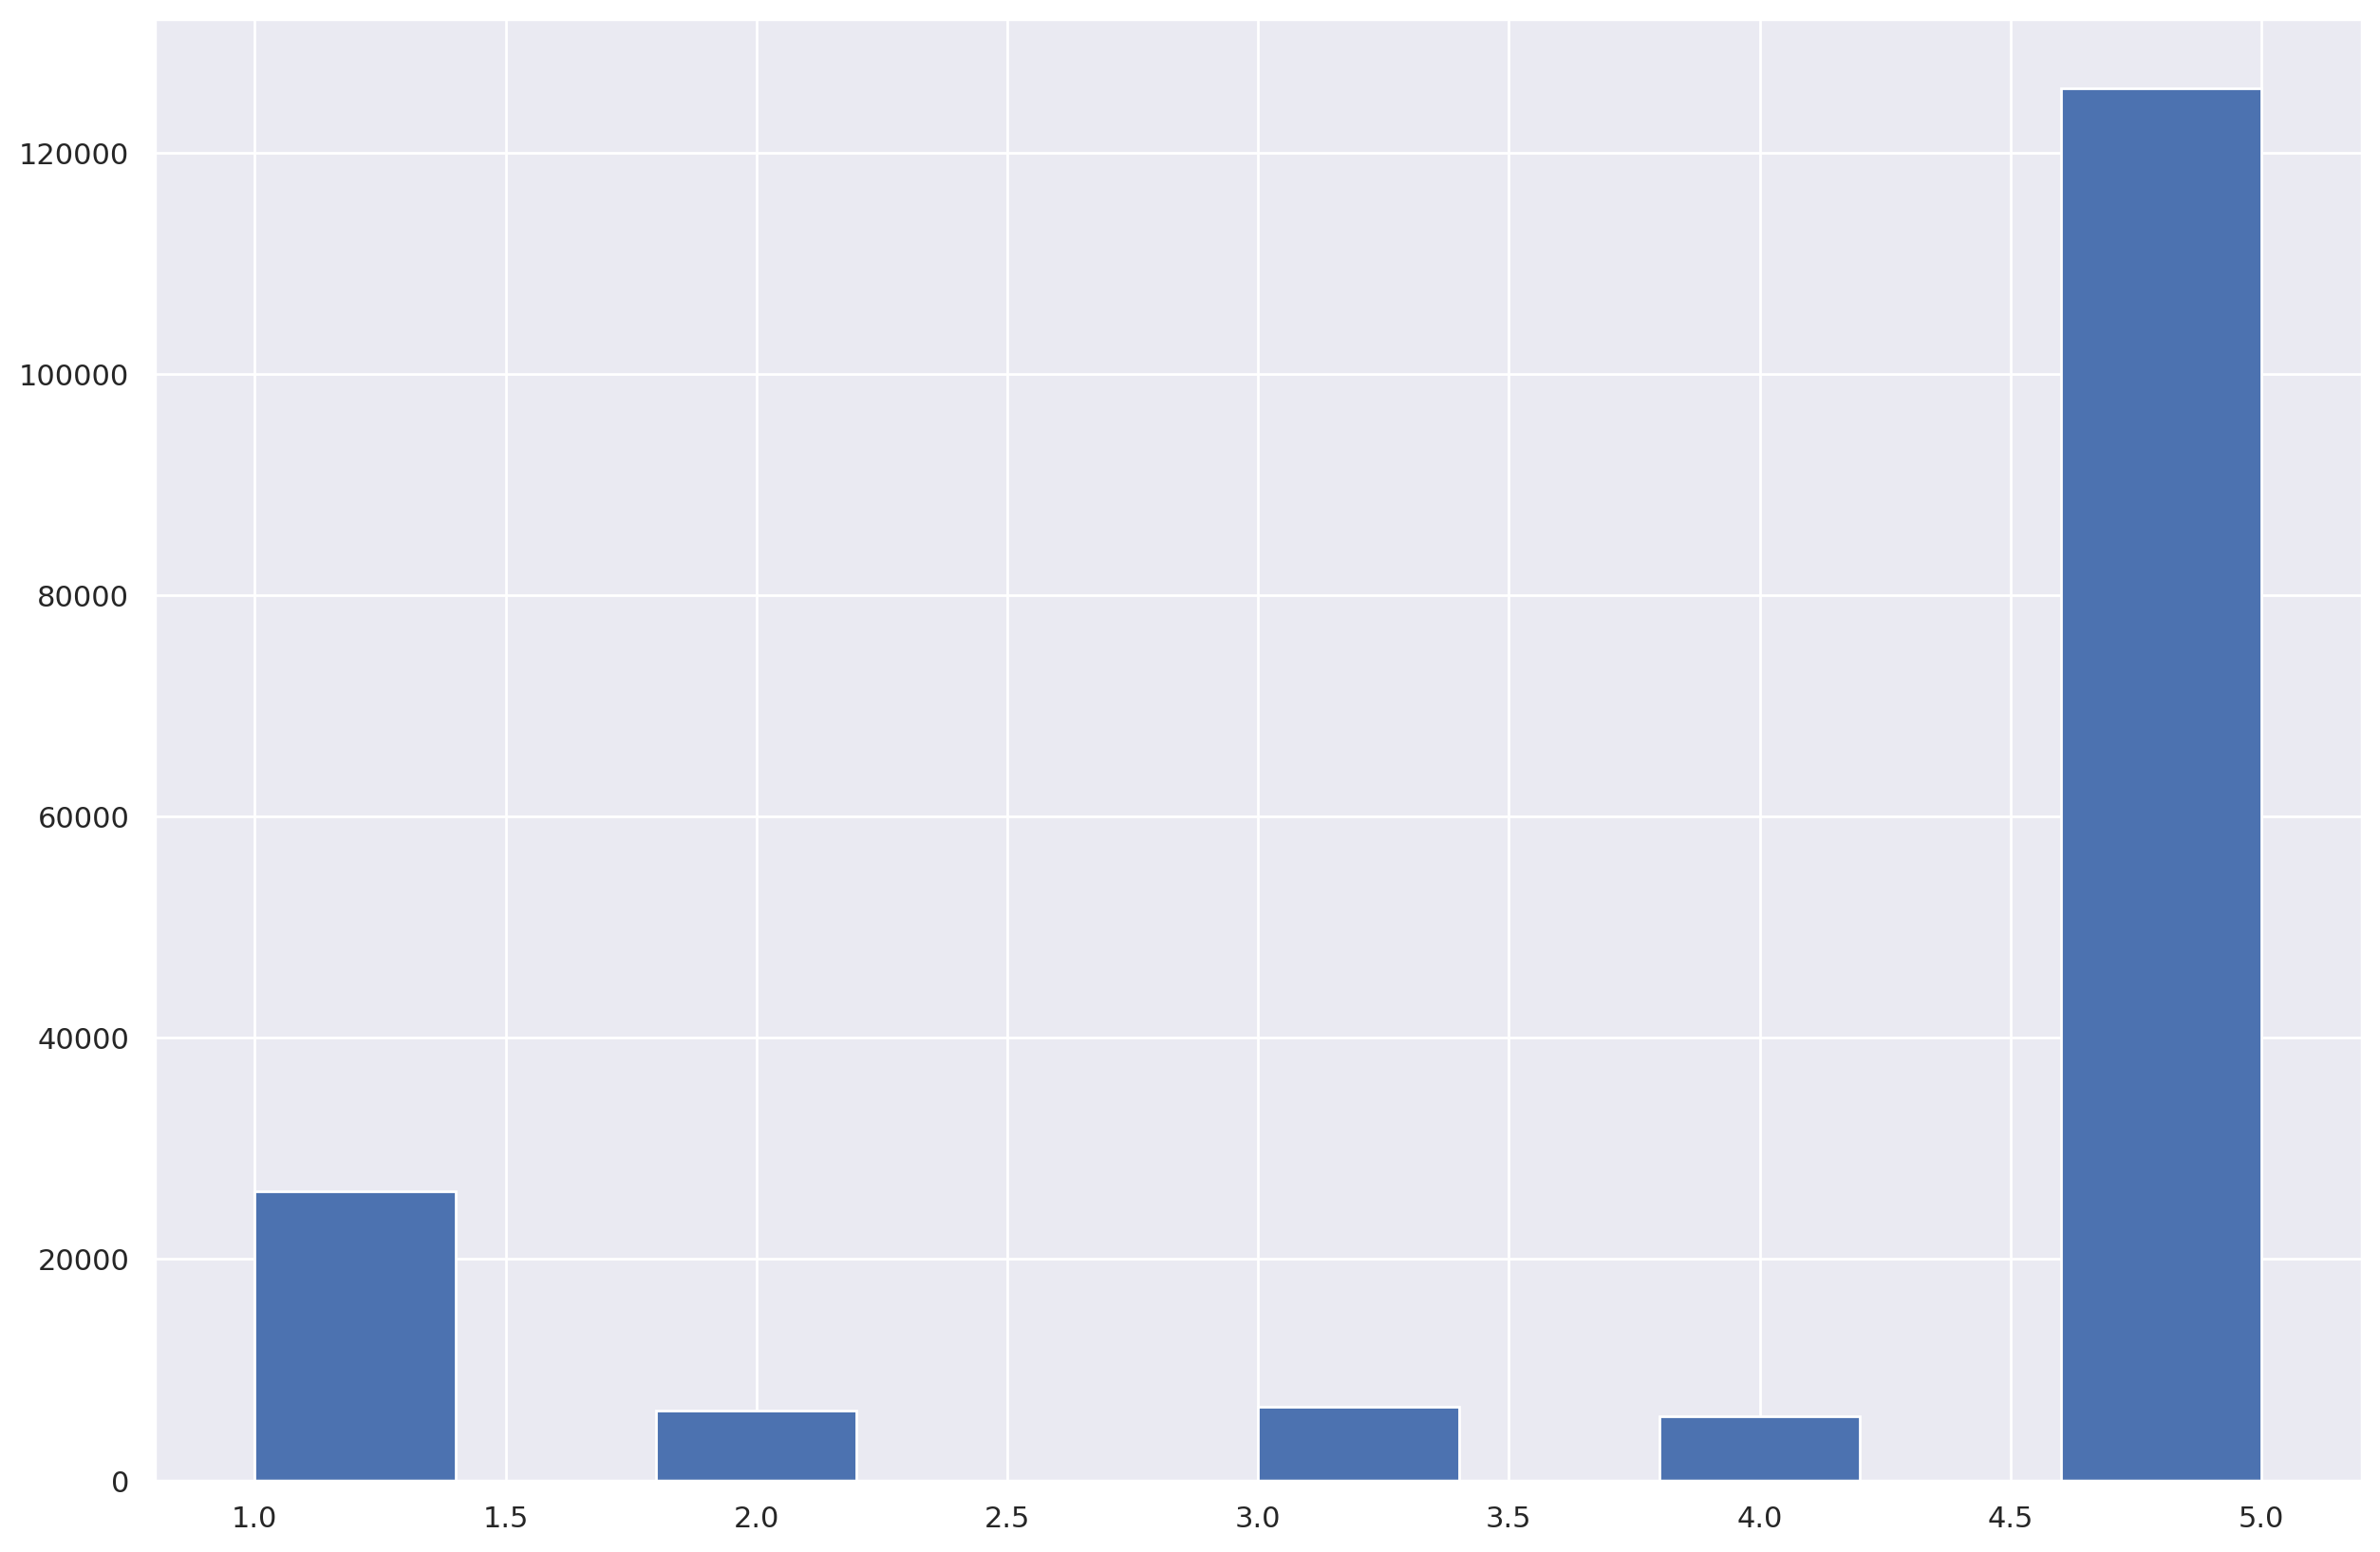

In [ ]:
plt.hist(df_alfagiftrev['score'])
plt.show()

**6. Penyimpanan Data**

DataFrame yang sudah diproses (`df_alfagiftrev`) kemudian disimpan ke dalam file CSV bernama `df_alfagift.csv` untuk penggunaan lebih lanjut atau analisis di masa mendatang.

In [ ]:
df_alfagiftrev.to_csv(r'df_alfagift.csv', index=False)